# Symbolická matematika v Jupyter Notebooku

Na rozdiel od predchádzajúcich notebookov, kde sme počítali
numericky, SymPy pracuje s matematickými výrazmi analyticky,
teda presne tak ako pri ručnom výpočte na papieri.

Výsledky sa zobrazujú v matematickej notácii priamo v bunke
notebooku – Jupyter Notebook tak dokáže nahradiť klasické
odvodenia na tabuli.

| Operácia | Príkaz | Popis |
|----------|--------|-------|
| Derivovanie | `sp.diff(f, x)` | Derivácia funkcie f podľa x |
| Integrovanie | `sp.integrate(f, x)` | Neurčitý integrál |
| Riešenie rovníc | `sp.solve(eq, x)` | Analytické riešenie |
| Diferenciálne rovnice | `sp.dsolve(ode, f(x))` | Riešenie ODE |
| Zjednodušenie | `sp.simplify(expr)` | Zjednodušenie výrazu |
| LaTeX výstup | `sp.latex(expr)` | Generovanie LaTeX kódu |

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.integrate import solve_ivp

sp.init_printing(use_latex=True)
%matplotlib inline

## 1. Symbolické premenné a kinematika

Najprv deklarujeme symbolické premenné s ich vlastnosťami.
Potom symbolicky odvodíme rýchlosť a zrýchlenie z polohy
– to isté, čo by sme robili na tabuli.

In [ ]:
# Symbolické premenné
t  = sp.Symbol('t',   real=True, positive=True)
s0 = sp.Symbol('s_0', real=True)
v0 = sp.Symbol('v_0', real=True)
a0 = sp.Symbol('a_0', real=True)
m  = sp.Symbol('m',   positive=True)
k  = sp.Symbol('k',   positive=True)
b  = sp.Symbol('b',   nonnegative=True)

# Poloha ako funkcia času
s_t = s0 + v0*t + sp.Rational(1,2)*a0*t**2

print("Poloha s(t):")
display(sp.Eq(sp.Function('s')(t), s_t))

# Derivovanie = rýchlosť
v_t = sp.diff(s_t, t)
print("\nRýchlosť v(t) = ds/dt:")
display(sp.Eq(sp.Function('v')(t), v_t))

# Druhá derivácia = zrýchlenie
a_t = sp.diff(s_t, t, 2)
print("\nZrýchlenie a(t) = d²s/dt²:")
display(sp.Eq(sp.Function('a')(t), a_t))

print("\nZrýchlenie je konštanta a₀ – potvrdenie rovnomerne zrýchleného pohybu.")

## 2. Analytické riešenie pohybovej rovnice

Toto je najsilnejšia ukážka SymPy: analytické riešenie
diferenciálnej rovnice druhého rádu. SymPy nájde všeobecné
riešenie pohybovej rovnice tlmeného oscilátora vrátane
integračných konštánt – bez akéhokoľvek numerického
zaokrúhľovania.

Pohybová rovnica:


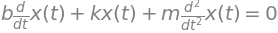


Všeobecné riešenie:



C1, C2 sú integračné konštanty určené z počiatočných podmienok x(0) a v(0).
Výraz pod odmocninou určuje režim tlmenia:
  b² - 4km < 0  →  podtlmený   (komplexné korene → kmitanie)
  b² - 4km = 0  →  kritický    (dvojnásobný koreň)
  b² - 4km > 0  →  pretlmený  (reálne korene → žiadne kmitanie)


In [3]:
# Pohybová rovnica: m·x'' + b·x' + k·x = 0
x_fn = sp.Function('x')

ode = sp.Eq(
    m * x_fn(t).diff(t,2) + b * x_fn(t).diff(t) + k * x_fn(t),
    0
)
print("Pohybová rovnica:")
display(ode)

# SymPy nájde analytické riešenie
print("\nVšeobecné riešenie:")
riesenie = sp.dsolve(ode, x_fn(t))
display(riesenie)

print("\nC1, C2 sú integračné konštanty určené z počiatočných podmienok x(0) a v(0).")
print("Výraz pod odmocninou určuje režim tlmenia:")
print("  b² - 4km < 0  →  podtlmený   (komplexné korene → kmitanie)")
print("  b² - 4km = 0  →  kritický    (dvojnásobný koreň)")
print("  b² - 4km > 0  →  pretlmený  (reálne korene → žiadne kmitanie)")

## 3. Symbolické vzorce a generovanie LaTeX

SymPy symbolicky odvodí vlastnú frekvenciu, kritické tlmenie
a automaticky vygeneruje LaTeX kód – použiteľný priamo
v záverečnej práci.

Vlastná uhlová frekvencia ω₀:



Kritické tlmenie b_krit = 2√(km):



Pomer tlmenia ζ = b / b_krit:


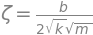


──────────────────────────────────────────────────
LaTeX kód pre použitie v záverečnej práci:
──────────────────────────────────────────────────
  ω₀:    $\frac{\sqrt{k}}{\sqrt{m}}$
  T:     $\frac{2 \pi \sqrt{m}}{\sqrt{k}}$
  b_krit: $2 \sqrt{k} \sqrt{m}$
  ζ:     $\frac{b}{2 \sqrt{k} \sqrt{m}}$


In [4]:
# Vlastná uhlová frekvencia
omega0 = sp.sqrt(k/m)
print("Vlastná uhlová frekvencia ω₀:")
display(sp.Eq(sp.Symbol('omega_0'), omega0))

# Kritické tlmenie
b_krit = 2 * sp.sqrt(k*m)
print("\nKritické tlmenie b_krit = 2√(km):")
display(sp.Eq(sp.Symbol('b_{krit}'), b_krit))

# Pomer tlmenia
zeta = sp.simplify(b / b_krit)
print("\nPomer tlmenia ζ = b / b_krit:")
display(sp.Eq(sp.Symbol('zeta'), zeta))

# LaTeX kód
print("\n" + "─"*50)
print("LaTeX kód pre použitie v záverečnej práci:")
print("─"*50)
print(f"  ω₀:    ${sp.latex(omega0)}$")
print(f"  T:     ${sp.latex(sp.simplify(2*sp.pi/omega0))}$")
print(f"  b_krit: ${sp.latex(b_krit)}$")
print(f"  ζ:     ${sp.latex(zeta)}$")

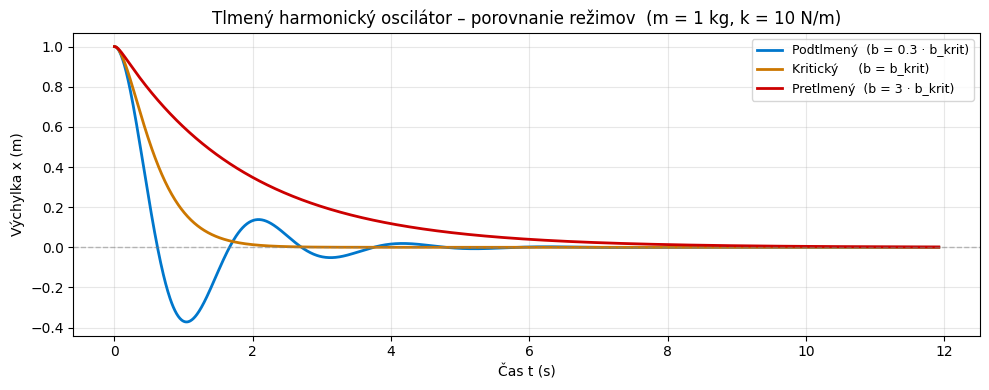

In [5]:
# Numerická vizualizácia troch režimov tlmenia
m_val = 1.0
k_val = 10.0
b_krit_val = float(2 * np.sqrt(k_val * m_val))
T_val = float(2 * np.pi / np.sqrt(k_val / m_val))
t_sim = np.linspace(0, 6*T_val, 1500)

fig, ax = plt.subplots(figsize=(10, 4))

for b_por, farba, nazov in [
    (b_krit_val * 0.3, '#0077CC', 'Podtlmený  (b = 0.3 · b_krit)'),
    (b_krit_val * 1.0, '#CC7700', 'Kritický     (b = b_krit)'),
    (b_krit_val * 3.0, '#CC0000', 'Pretlmený  (b = 3 · b_krit)')
]:
    sol = solve_ivp(
        lambda t, y, bp=b_por: [y[1], (-bp*y[1] - k_val*y[0])/m_val],
        (0, 6*T_val), [1.0, 0.0],
        t_eval=t_sim, method='RK45'
    )
    ax.plot(sol.t, sol.y[0], color=farba, lw=2, label=nazov)

ax.axhline(y=0, color='gray', lw=1, ls='--', alpha=0.5)
ax.set_xlabel('Čas t (s)')
ax.set_ylabel('Výchylka x (m)')
ax.set_title('Tlmený harmonický oscilátor – porovnanie režimov  (m = 1 kg, k = 10 N/m)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

![Porovnanie troch režimov tlmenia](_images/harmon.png)
*Obr. Porovnanie podtlmeného, kriticky tlmeného a pretlmeného režimu.*

## Záver

SymPy rozširuje Jupyter Notebook o analytickú matematiku:

- Derivovanie a integrovanie dáva exaktné vzorce bez numerickej chyby
- Riešenie ODE poskytuje všeobecné analytické riešenie pohybovej rovnice
- Automatické generovanie LaTeX kódu umožňuje vzorce priamo použiť
  v odborných textoch a záverečných prácach